Regression und Auswertung der Residuen, also reale Werte vom Target minus vorhergesagte, handelt es sich um eine fehlerbasierte (überwachte) Anomalieerkennung. Also welche Targetwerte sind ungeöhnlich. Es werden exotische Ergebnisse gesucht, die nicht zu den Bedingungen passen. Es wird das Verhalten von y im Verhältnis zu X gemessen.<br>
Der isolation forest ist eine strukturbasierte (unüberwachte) Anomalieerkennung. Welche Kombinationen der Randbedingungen (Featurewerte) sind ungewöhnlich, unabhängig vom Target. Es werden also exotische Zustände gefunden!

Unterscheidung wichtig zwischen:
- Verbesserung des Regressionsmodells durch Beseitung der Bedinungen die auffällig sind. (Hier wird der Fokus auf die Kombination gelegt)
- Allgemeine Betrachtung für Erkenntnisgewinn (Gesamtanalyse), um unlogische Verhaltensweise oder widersprüchliche Gesamtzustände aufzudecken. Hier werden globale Ausreißer gefunden! Keine konditionalen (nur in spezifischer Kombination seltsam).

In beiden Fällen werden die Datensätze einzeln betrachtet. Aber:

- Die Regression straft das unlogische Verhalten eines Datensatzes ab (Abweichung von der Formel).
- Der Isolation Forest straft die Einsamkeit eines Datensatzes ab (wie schnell lässt er sich von allen anderen trennen).

1. Die Regression: Der "Spezialist" für den clo-WertFokus: Die Regression ist darauf getrimmt, den clo-Wert aus den 10 Rahmenbedingungen (\(X\)) vorherzusagen. Sie bewertet die Daten durch die Brille der Kausalität (Ursache und Wirkung).Auswirkung: Sobald der echte clo-Wert massiv von der physikalisch-logischen Erwartung abweicht, schlägt das Modell maximalen Alarm (großes Residuum). Der clo-Wert steht hier unter einem permanenten Brennglas.
2. Der Isolation Forest: Der "Demokrat" im RaumFokus: Der Isolation Forest behandelt alle 11 Spalten absolut gleichberechtigt. Er kennt kein "Target" und sucht nicht nach Ursachen, sondern rein nach geometrischer Einsamkeit (Datendichte).Auswirkung: Da deine 8 Punkte in 10 von 11 Dimensionen mitten im dicht besiedelten Zentrum liegen, "schützen" die vielen Nachbarn diese Punkte. Die Abweichung in der einen clo-Dimension wird mathematisch durch die extreme Normalität in den anderen 10 Dimensionen schlichtweg demokratisch überstimmt und verwässert.

Der Isolation Forest sollte nicht mit zuvielen Features gefüttert werden!!!

Fluch der Dimensionalität. Während bei der Regression 100% der Wichtigkeit bei clo liegt, ist es beim Isolation Forest so, dass die Wichtigkeit bei clo bei 1/Anzahl Features liegt und somit bei 11 Stück unter 10%!!! Die Regression filtert "Nachbarn", der Isolation Forest wird von ihnen erdrückt.

Es sind zwei Szenarios zu unterscheiden:

- Szenario A: Du suchst Eingabefehler & Sensorausreißer (Datenqualität)
    - Strategie: Nimm nur die kontinuierlichen, physikalischen Messwerte (air_speed, metabolic_rate, temperature). Jedes fehlerhafte Komma oder tote Messgerät fliegt sofort auf.

- Szenario B: Du suchst physikalische Widersprüche (wie dein clo-Problem)
    - Strategie: Nimm extrem wenige Features (maximal 4–5), die in einer direkten physikalischen Wechselwirkung zueinander stehen. Lösche alle administrativen oder rein kategorischen Hintergrunddaten (wie country), da sie sonst als Schutzschild für Ausreißer fungieren.

Der Isolation Forest ein holistischer Dichteschätzer ist, dessen Sensitivität für spezifische Variablen-Widersprüche durch eine zu hohe Dimensionalität drastisch gegen Null sinkt.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [ ]:
## df = pd.read_csv("db_bereinigt.csv")  # alte csv

#df = pd.read_csv("db_bereinigt_fertig.csv") # aktuelle Datenbank Stand 06.07.2026

df = pd.read_csv("db_bereinigt_final.csv") # aktuelle Datenbank Stand 13.07.2026

In [ ]:
'''
# Daten aus Datenbank einlesen

from sqlalchemy import create_engine
import os
from dotenv import load_dotenv

load_dotenv()
db_password = os.getenv("DB_PASSWORD")

# Verbindungsdaten anpassen
db_user = 'neondb_owner'
db_host = 'ep-summer-band-aselkm9n-pooler.c-4.eu-central-1.aws.neon.tech'
db_port = '5432'
db_name = 'neondb'

# Engine erstellen
engine = create_engine(f'postgresql+psycopg2://{db_user}:{db_password}@{db_host}:{db_port}/{db_name}')

# SQL-Query definieren und Daten in den DataFrame laden
query = "SELECT * FROM ashrae_consolidado"
df = pd.read_sql(query, con=engine)

# Erste Zeilen zur Kontrolle anzeigen
display(df.head())
'''

In [ ]:
print(type(df))

In [ ]:
df

In [21]:
# Target Kleidungsisolationswert
#df_ml_clo = df[['outdoor_air_temperature', 'air_temperature', 'relative_humidity', 'season', 'country', 'building_type', 'air_speed', 'clothing_ensemble_insulation']] #   Basis 0,13 MAE
#df_ml_clo = df[['outdoor_air_temperature', 'air_temperature', 'relative_humidity', 'season', 'country', 'building_type', 'air_speed', 'metabolic_rate', 'clothing_ensemble_insulation']]   # MAE 0,12
#df_ml_clo = df[['outdoor_air_temperature', 'air_temperature', 'relative_humidity', 'season', 'country', 'building_type', 'air_speed', 'metabolic_rate', 'climate', 'clothing_ensemble_insulation']]
#df_ml_clo = df[['outdoor_air_temperature', 'air_temperature', 'relative_humidity', 'season', 'country', 'building_type', 'air_speed', 'metabolic_rate', 'climate', 'cooling_type', 'clothing_ensemble_insulation']]

df_ml_clo = df[['outdoor_air_temperature', 'air_temperature', 'relative_humidity', 'season', 'building_type', 'air_speed', 'metabolic_rate', 'cooling_type', 'clothing_ensemble_insulation']]

# Vergleich mit DBSCAN und Regression
#df_ml_clo = df[['outdoor_air_temperature', 'air_temperature', 'relative_humidity', 'air_speed', 'metabolic_rate', 'clothing_ensemble_insulation']]

In [22]:
df_ml_clo['cooling_type'] = df_ml_clo['cooling_type'].replace(['unknown', 'Unknown', 'UNKNOWN', 'nan', 'None'], np.nan)
df_ml_clo

C:\Users\User\AppData\Local\Temp\ipykernel_30204\157953021.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_ml_clo['cooling_type'] = df_ml_clo['cooling_type'].replace(['unknown', 'Unknown', 'UNKNOWN', 'nan', 'None'], np.nan)


,outdoor_air_temperature,air_temperature,relative_humidity,season,building_type,air_speed,metabolic_rate,cooling_type,clothing_ensemble_insulation
0,15.86,22.3,61.0,winter,office,0.03,1.706485,mixed mode,0.95
1,15.86,23.0,59.0,winter,office,0.08,1.109215,mixed mode,1.07
2,15.86,22.0,61.0,winter,office,0.04,1.211604,mixed mode,0.88
3,15.86,23.2,58.0,winter,office,0.03,1.774744,mixed mode,0.59
4,15.86,22.2,62.0,winter,office,0.15,1.484642,mixed mode,0.83
...,...,...,...,...,...,...,...,...,...
109028,NaN,27.6,64.0,hot/wet,others,NaN,1.100000,air conditioned,0.64
109029,NaN,28.3,66.0,hot/wet,others,NaN,1.100000,air conditioned,0.79
109030,NaN,28.3,66.0,hot/wet,others,NaN,1.100000,air conditioned,0.62
109031,NaN,28.3,66.0,hot/wet,others,NaN,1.200000,air conditioned,0.57


In [23]:
df_ml_clo_clean = df_ml_clo.dropna()

In [24]:
df_ml_clo_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 47584 entries, 0 to 107852
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   outdoor_air_temperature       47584 non-null  float64
 1   air_temperature               47584 non-null  float64
 2   relative_humidity             47584 non-null  float64
 3   season                        47584 non-null  object 
 4   building_type                 47584 non-null  object 
 5   air_speed                     47584 non-null  float64
 6   metabolic_rate                47584 non-null  float64
 7   cooling_type                  47584 non-null  object 
 8   clothing_ensemble_insulation  47584 non-null  float64
dtypes: float64(6), object(3)
memory usage: 3.6+ MB


In [ ]:
'''
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# ==========================================
# 1. BEISPIELDATEN ERSTELLEN (Gegen echte Daten tauschen)
# ==========================================
# Wir simulieren 200 normale Datenpunkte und 5 extreme Anomalien
np.random.seed(42)
normale_daten = np.random.normal(loc=10, scale=2, size=(200, 2))
anomalien = np.random.uniform(low=0, high=25, size=(5, 2))

# Kombinieren in ein Pandas DataFrame
X = pd.DataFrame(np.vstack([normale_daten, anomalien]), columns=['Feature_A', 'Feature_B'])

# ==========================================
# 2. VORVERARBEITUNG (Skalierung)
# ==========================================
# Obwohl Isolation Forests (da baumbasiert) resistent gegen unterschiedliche Skalen sind,
# hilft eine Standardisierung oft bei der Interpretation und Visualisierung.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# ==========================================
# 3. ISOLATION FOREST CONFIGURATION
# ==========================================
# Der wichtigste Parameter ist 'contamination' (der erwartete Anteil an Anomalien)
iso_forest = IsolationForest(
    n_estimators=100,          # Anzahl der Bäume im Wald
    contamination=0.03,        # Schätzwert: ca. 3% der Daten sind schätzungsweise Anomalien
    max_samples='auto',        # Anzahl der Samples pro Baum
    random_state=42,           # Reproduzierbarkeit
    n_jobs=-1                  # Nutzt alle CPU-Kerne für schnelles Rechnen
)

# Modell fitten und Vorhersage treffen
# (Bei Unsupervised Learning fitten und predicten wir auf denselben Daten)
predictions = iso_forest.fit_predict(X_scaled)

# ==========================================
# 4. ERGEBNISSE AUSWERTEN
# ==========================================
# Der Isolation Forest gibt zwei wichtige Informationen zurück:
# predictions:  1 = Normaler Datenpunkt | -1 = Anomalie
# anomaly_scores: Je niedriger/negativer der Score, desto stärker die Anomalie

X_results = X.copy()
X_results['Ist_Anomalie'] = predictions
X_results['Anomalie_Score'] = iso_forest.decision_function(X_scaled)

# Filterung der gefundenen Anomalien
gefundene_anomalien = X_results[X_results['Ist_Anomalie'] == -1]

print(f"Gesamtanzahl Datenpunkte: {len(X_results)}")
print(f"Gefundene Anomalien (bei contamination=0.03): {len(gefundene_anomalien)}\n")

print("Die Top-Anomalien sortiert nach dem stärksten Score:")
print(gefundene_anomalien.sort_values(by='Anomalie_Score').head())
'''

In [27]:
# Preprozessor aus Regression, primär feature encoding
# Durch die Verwendung des TargetEncoder kann diese Pipeline nicht zusammen mit dem Target eingesetzt werden, sondern nur für Anomalieanalysen zum Filter der Bedingungen für die Regression.

# Anders als beim DBSCAN, wo Dichtewolken analysiert werden, können und sollten kategorische Features beim Isolation Forest im Modell bleiben
# Eine Skalierung der kontinuierlichen Features ist nicht erforderlich, somit unterscheidet sich der Isolation Forest stark von DBSCAN!

import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, PowerTransformer
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

from sklearn.preprocessing import OneHotEncoder, TargetEncoder

X = df_ml_clo_clean.drop(columns=['clothing_ensemble_insulation'])
y = df_ml_clo_clean['clothing_ensemble_insulation']


 # durch den one-hot-encoder entstehen 52 Spalten, grundsätzlich kein Problem für den isolation forest
 # deshalb werden kategorische Anomalien leichter gefunden als die physikalischen (Verwässerungsproblem)
 # deshalb entweder alternativ den target-encoder verwenden (elegantere Lösung)
 # oder max_features=0.5 im Algorithmus verwenden
categorial_features = [
    "season",
    "building_type",
    "cooling_type",
]

# Target encoder sind keine gute Wahl in Isolation Forest Modellen - sehr riskant, gerade da hier daraus die relevantesten Features entstehen
#targenc_features = [
##    "climate",
#    "country"
#    ]

feature_names = df_ml_clo_clean.drop(columns=['clothing_ensemble_insulation']).columns.tolist()

# Spalten aufteilen: Nur 'feature_0' und 'feature_1' sollen skaliert werden
##columns_to_scale = ['air_speed', 'metabolic_rate']
columns_to_scale = ['air_speed', 'outdoor_air_temperature']
other_columns = [col for col in feature_names if col not in columns_to_scale]

# 2. Train-Test-Split # nur sinnvoll für Vorbereitung der Regression
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)   


# 3. ColumnTransformer für gezielte Skalierung
preprocessor = ColumnTransformer(
    transformers=[
        #('num_scaler', StandardScaler(), columns_to_scale),
        ('power_transform', PowerTransformer(method='yeo-johnson'), columns_to_scale),
        ('cat_encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorial_features),   # sparse_output für GradientBoostingRegrressor # alternativ wäre ein ordinal encoding denkbar

#        ('target_encoder', TargetEncoder(smooth="auto", cv=5, random_state=42), targenc_features)  # hier wird y mit berücksichtigt, deshalb wird y unten benötigt im fit!!!! Alternativ wäre es wahrscheinlich sinnvoll die Anzahl der Klimazonen zu reduzieren und einen anderen encoder zu verwenden
    ],
    remainder='passthrough', # Verbleibende Spalten bleiben unverändert
    verbose_feature_names_out=False
)

# Für Vergleich mit DBSCAN - Pipeline überbrücken, da nur noch ein Set vorhanden ist und das nur numerischen Werte hat
#preprocessor = ColumnTransformer(transformers=[], remainder='passthrough')


In [28]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

'''
Anomalieerkennung braucht eigentlich keine vierer Aufteilung. Hier nur die Aufteilung in Train und Testset, um ggf. das Modell der Regression zu modifizieren.
Außerdem wurden in der Pipeline Encoder verwendet, deshalb wird beim fit nicht nur X, sondern auch y benötigt.
Normalerweise würde man einen kompletten dataframe in fit_predict werfen!
'''

# 1. Pipeline definieren
# 'preprocessor' ist hier der bereits existierender ColumnTransformer
anomaly_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor), 
    ('anomaly_detector', IsolationForest(
        n_estimators=100,
        #contamination=0.02, # Schätzung: 2% Ausreißer
        #contamination=0.00001,  # Minert, muss zwischen 0 und 0.5 liegen offenes Intervall, also exklusive der Randwerte
        #contamination=0.5, # Maxwert
#        contamination=0.013295, # Ausknick bei Kurve ermittelt

        contamination=0.00793669939449497,
       #contamination=0.00897, # Ausknick bei Kurve ermittelt für Train Test Split

        #contamination=0.01, # für dbscan-Vergleich

        #contamination='auto',  #   für ersten Durchlauf zum Ermitteln des richtigen Wertes
        random_state=42,
        n_jobs=-1
    ))
])

# 2. Pipeline fitten und direkt Vorhersagen generieren
# Hinweis: Da IsolationForest kein y benötigt, übergeben wir nur X_train
# predictions = anomaly_pipeline.fit_predict(X_train)   # Wäre okay ohne target encoding, da hier aber target encoding ist y_train doch erforderlich

# Block angepasst wegen target_encoding
anomaly_pipeline.fit(X_train, y_train)  # y_train wird für das Trainieren ignoriert!!!!    x_train wird über pipeline encoded, y wird aber in der Pipeline benötigt!!!
X_train_preprocessed = anomaly_pipeline.named_steps['preprocessor'].transform(X_train)  # für spätere plots und zum predicten, xtrain wird umgewandelt und in der Form als dataframe abgespeichert. Es entssteht ein rein numerischer dataframe.

'''
# -1 und 1 als prediction
#predictions = anomaly_pipeline.named_steps['anomaly_detector'].predict(X_test_preprocessed if 'X_test_preprocessed' in locals() else X_train_preprocessed)
#predictions = anomaly_pipeline.named_steps['anomaly_detector'].predict(X_train_preprocessed)   #   Suchen nach Anomalien im trainset
predictions = anomaly_pipeline.predict(X_train)   #   Suchen nach Anomalien im trainset


# kontinuierliche predictions
#input_data = X_test_preprocessed if 'X_test_preprocessed' in locals() else X_train_preprocessed
#anomaly_scores = anomaly_pipeline.named_steps['anomaly_detector'].decision_function(input_data)
#anomaly_scores = anomaly_pipeline.named_steps['anomaly_detector'].decision_function(X_train_preprocessed)   #   Suchen nach Anomalien im trainset
anomaly_scores = anomaly_pipeline.decision_function(X_train)



# 3. Ergebnisse im ursprünglichen DataFrame speichern
X_train_analyzed = X_train.copy()
X_train_analyzed['Anomalie_Label'] = predictions # 1 = normal, -1 = anomal



# 4. Den kontinuierlichen Anomalie-Score auslesen
# Da die Pipeline den Score nicht direkt per Methode anbietet, 
# greifen wir über 'named_steps' auf das Modell zu.
# Wichtig: Die decision_function benötigt die bereits vorverarbeiteten Daten!
X_train_preprocessed = anomaly_pipeline.named_steps['preprocessor'].transform(X_train)
X_train_analyzed['Anomalie_Score'] = anomaly_pipeline.named_steps['anomaly_detector'].decision_function(X_train_preprocessed)

# Ergebnisse anzeigen
anomalien = X_train_analyzed[X_train_analyzed['Anomalie_Label'] == -1]
print(f"Es wurden {len(anomalien)} Anomalien in den Trainingsdaten identifiziert.")

scores = anomaly_pipeline.named_steps['anomaly_detector'].decision_function(X_train_preprocessed)
'''

anomaly_scores = anomaly_pipeline.decision_function(X_train)

X_train_analyzed = X_train.copy()
X_train_analyzed['Anomalie_Score'] = anomaly_scores

X_train_analyzed['Anomalie_Label'] = anomaly_pipeline.predict(X_train)

anomalien = X_train_analyzed[X_train_analyzed['Anomalie_Label'] == -1]
print(f"Es wurden {len(anomalien)} Anomalien in den Daten identifiziert.")


Es wurden 303 Anomalien in den Daten identifiziert.


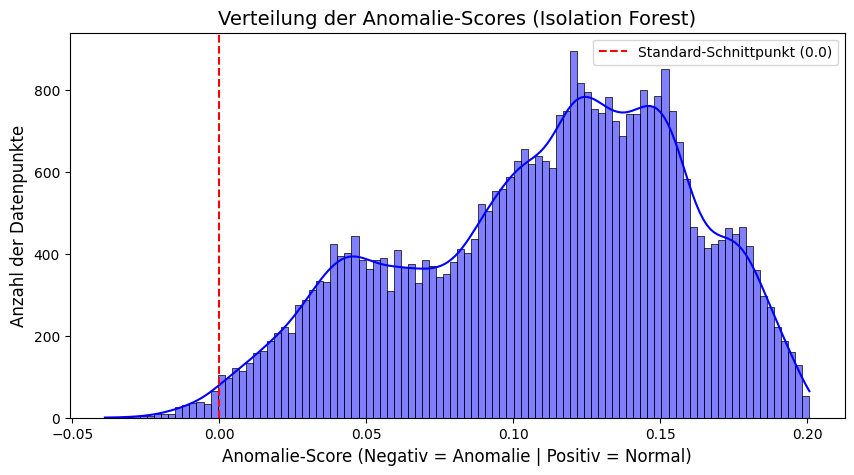

In [29]:
plt.figure(figsize=(10, 5))
# Ein Histogramm mit einer Dichtelinie (KDE) zeichnen
sns.histplot(anomaly_scores, bins=100, kde=True, color='blue')

# Titel und Achsenbeschriftung
plt.title("Verteilung der Anomalie-Scores (Isolation Forest)", fontsize=14)
plt.xlabel("Anomalie-Score (Negativ = Anomalie | Positiv = Normal)", fontsize=12)
plt.ylabel("Anzahl der Datenpunkte", fontsize=12)

# Eine rote Linie bei 0.0 zeichnen (Der Standard-Schwellenwert von Scikit-Learn)
plt.axvline(x=0, color='red', linestyle='--', label='Standard-Schnittpunkt (0.0)')
plt.legend()
plt.show()

# Diese Graphik muss erstmal durch einen ersten Durchlauf des isolation forest erstelle werden. Danach kann man einen contamination-Wert bestimmen.

In [ ]:
contamination_wert = (anomaly_scores < -0.088).mean()
#contamination_wert = (anomaly_scores < -0.095).mean()   # hier Wert eintragen aus Diagramm
#contamination_wert = (anomaly_scores < -0.12).mean()   # hier Wert eintragen aus Diagramm
print(f"contamination_wert oben für den estimator: {contamination_wert}")


Vorgehensweise: 
- Estimator mit auto durchlaufen lassen
- Scoreplot erstellen
- über den x Wert im Plot die Linie verschieben, bis sie die Anomalie abschneidet
- contamination_wert über die Gleichung ermitteln
- contamination_wert im Estimator eintragen
- Plot mit x=0 prüfen, ob das Diagramm den Schnitt richtig setzt

In [ ]:
#df_pairplot = X_train.copy()

#df_pairplot['Status'] = ['Anomalie' if label == -1 else 'Normal' for label in predictions]

#anomalien

features_zum_plotten = ['air_temperature', 'outdoor_air_temperature', 'air_speed']

transparente_palette = {
     1: '#4C72B026',  # Normal: Stark transparent (Alpha ~ 0.15)
    -1: '#C44E52FF'   # Anomalie: Voll deckend (Alpha = 1.0)
}

sns.pairplot(
    data=X_train_analyzed,
    hue='Anomalie_Label',                  
    vars=features_zum_plotten,     
    palette=transparente_palette,  # Unsere neue Palette mit eingebautem Alpha
    plot_kws={'edgecolor': 'none'}, # WICHTIG: Das globale 'alpha' hier löschen!
    diag_kind='kde'                
)

plt.suptitle("Visualisierung der identifizierten Anomalien im Feature-Raum", y=1.02, fontsize=14)
plt.show()

In [ ]:
df_plot = X_train_analyzed.copy()
df_plot["Is_Anomaly"] = df_plot["Anomalie_Label"].map({-1: True, 1: False})



features_zum_plotten = [
    'outdoor_air_temperature', 
    'air_temperature', 
    'relative_humidity', 
    'air_speed', 
    ##'metabolic_rate', 
]

# 2. Die Farbpalette mit eingebauter Transparenz (Alpha) definieren
# '33' am Ende von #008080 (Teal) macht die Masse sehr transparent (~20% Deckkraft)
# 'FF' am Ende von #FF0000 (Red) macht die Anomalien zu 100% deckend
transparente_palette = {
     #1: '#00808033',  # Normal: Dezentes, transparentes Teal
    False: '#008080FF',  # Normal: Dezentes, transparentes Teal
    True: '#FF0000FF'   # Anomalie: Knalliges, voll deckendes Rot
}

# 3. Den Pairplot aufbauen
sns.pairplot(
    data=df_plot,
    hue='Is_Anomaly',           # Spaltenname Ihrer -1/1 Vorhersagen
    vars=features_zum_plotten,      # Die physikalischen Achsen des Gitters
    palette=transparente_palette,   # Unsere Farb- und Transparenzsteuerung
    markers=['o', 'X'],             # 'o' für Normal (Punkt), 'X' für Anomalie (Kreuz)
    #plot_kws={'edgecolor': 'none'}, # Verhindert schwarze Ränder um die Punkte
    diag_kind='kde'                 # Zeigt die glatten Verteilungskurven auf der Diagonale
)

# 4. Titel hinzufügen und anzeigen
plt.suptitle('Pairplot der Features mit markierten Anomalien', y=1.02, fontsize=14)
plt.show()

#del df_plot

In [ ]:
df_plot = X_train_analyzed.copy()
df_plot["Is_Anomaly"] = df_plot["Anomalie_Label"].map({-1: True, 1: False})

# ==================================================================
# ERGÄNZUNG: Sortiert Anomalien nach unten, damit sie zuletzt (obenauf) 
# gezeichnet werden. Alle anderen Einstellungen bleiben unberührt.
# ==================================================================
df_plot = df_plot.sort_values(by="Is_Anomaly", ascending=True)

features_zum_plotten = [
    'outdoor_air_temperature', 
    'air_temperature', 
    'relative_humidity', 
    'air_speed', 
    ##'metabolic_rate', 
]

# 2. Die Farbpalette mit eingebauter Transparenz (Alpha) definieren
# '33' am Ende von #008080 (Teal) macht die Masse sehr transparent (~20% Deckkraft)
# 'FF' am Ende von #FF0000 (Red) macht die Anomalien zu 100% deckend
transparente_palette = {
     #1: '#00808033',  # Normal: Dezentes, transparentes Teal
    False: '#008080FF',  # Normal: Dezentes, transparentes Teal (aktiviert für den Plot)
    True: '#FF0000FF'   # Anomalie: Knalliges, voll deckendes Rot
}

# 3. Den Pairplot aufbauen
sns.pairplot(
    data=df_plot,
    hue='Is_Anomaly',           # Spaltenname Ihrer -1/1 Vorhersagen
    vars=features_zum_plotten,      # Die physikalischen Achsen des Gitters
    palette=transparente_palette,   # Unsere Farb- und Transparenzsteuerung
    markers=['o', 'X'],             # 'o' für Normal (Punkt), 'X' für Anomalie (Kreuz)
    #plot_kws={'edgecolor': 'none'}, # Verhindert schwarze Ränder um die Punkte
    diag_kind='kde'                 # Zeigt die glatten Verteilungskurven auf der Diagonale
)

# 4. Titel hinzufügen und anzeigen
plt.suptitle('Pairplot der Features mit markierten Anomalien', y=1.02, fontsize=14)
plt.show()


In [ ]:
'''
import numpy as np

# 1. Scores holen (deine gezeigten Werte)
scores = model.decision_function(X)

# 2. Schwellenwert beim 2%-Quantil ermitteln
threshold = np.percentile(scores, 2) 
print(f"Neuer Schwellenwert: {threshold}")

# 3. Vorhersage manuell anpassen (1 = Normal, -1 = Anomalie)
predictions = np.where(scores < threshold, -1, 1)
'''

In [ ]:
'''
# Wunsch-Schwellenwert definieren
mein_schwellenwert = -0.03

# Maske erstellen: Alles was GRÖSSER als der Schwellenwert ist, bleibt drin!
echte_daten_maske = scores >= mein_schwellenwert

# Datensatz filtern
X_train_custom_clean = X_train[echte_daten_maske]
y_train_custom_clean = y_train[echte_daten_maske]

# Berechnen, wie viel Prozent Sie damit gelöscht haben
geloeschte_punkte = len(X_train) - len(X_train_custom_clean)
prozent_geloescht = (geloeschte_punkte / len(X_train)) * 100

print(f"Gewählter Schwellenwert: {mein_schwellenwert}")
print(f"Es wurden {geloeschte_punkte} Punkte entfernt. Das entspricht exakt {prozent_geloescht:.2f}% der Daten.")
'''

In [ ]:
# Die 10 extremsten Anomalien anzeigen
top_anomalien = anomalien.sort_values(by='Anomalie_Score').head(10)
#display(top_anomalien[['season', 'climate', 'air_speed', 'metabolic_rate']])
display(top_anomalien[['outdoor_air_temperature', 'air_temperature', 'air_speed', 'relative_humidity', 'metabolic_rate']])

In [ ]:
'''
# 1. Sicherstellen, dass die Spalte in der analysierten Tabelle existiert
# (Dieser Schritt berechnet die Vorhersagen und fügt sie als Spalte hinzu)
X_train_analyzed = X_train.copy()
X_train_analyzed['Ist_Anomalie'] = anomaly_pipeline.named_steps['anomaly_detector'].predict(X_train_preprocessed)

# 2. HIER WAR DER FEHLER: Wir holen uns die Maske aus 'X_train_analyzed'
normale_daten_maske = (X_train_analyzed['Ist_Anomalie'] == 1)

# 3. Jetzt filtern wir das ursprüngliche X_train und y_train synchron
X_train_clean = X_train[normale_daten_maske]
y_train_clean = y_train[normale_daten_maske]

# 4. Kontrolle der Zeilenanzahl
print(f"Ursprüngliche Zeilen: {len(X_train)}")
print(f"Bereinigte Zeilen:     {len(X_train_clean)}")
'''

In [ ]:
# Neue Testdaten vorverarbeiten und auf Anomalien prüfen
# anders als DBSCAN, kann mit dem isolation forest jetzt auf eine Vorhersage mit neuen Daten getroffen werden
# hier eine Analyse mit den Testdaten
#X_test_preprocessed = anomaly_pipeline.named_steps['preprocessor'].transform(X_test)
#test_predictions = anomaly_pipeline.named_steps['anomaly_detector'].predict(X_test_preprocessed)

test_predictions = anomaly_pipeline.predict(X_test)


In [ ]:
# Zählen, wie oft die -1 (Anomalie) im Array vorkommt
anzahl_anomalien_test = np.sum(test_predictions == -1)
anzahl_normal_test = np.sum(test_predictions == 1)
gesamt_test = len(test_predictions)

# Prozentualen Anteil berechnen
anteil_anomalien = (anzahl_anomalien_test / gesamt_test) * 100

print(f"=== Ergebnisse Testdatensatz ===")
print(f"Gesamtanzahl im Testset: {gesamt_test}")
print(f"Normale Datenpunkte:    {anzahl_normal_test}")
print(f"Erkannte Anomalien:     {anzahl_anomalien_test} ({anteil_anomalien:.2f}%)")


In [ ]:
# 1. Spalte in einer Kopie von X_test anlegen, um Warnungen zu vermeiden
X_test_analyzed = X_test.copy()
X_test_analyzed['Ist_Anomalie'] = test_predictions

# 2. Die Anomalien in ein eigenes DataFrame filtern
test_anomalien = X_test_analyzed[X_test_analyzed['Ist_Anomalie'] == -1]

print(f"Anzahl gefundener Anomalien im Testset: {len(test_anomalien)}\n")

# 3. Die ersten 5 Anomalien im Testset anzeigen lassen
print("Einblick in die Anomalien des Testdatensatzes:")
display(test_anomalien)


In [ ]:
import shap
import matplotlib.pyplot as plt

# 1. Den Explainer explizit auf die decision_function ansetzen
# (Wichtig: Wir übergeben das Modell aus der Pipeline)
model_to_explain = anomaly_pipeline.named_steps['anomaly_detector']
explainer_anomaly = shap.TreeExplainer(model_to_explain)


# 2. SHAP-Werte für die vorverarbeiteten Daten berechnen
# (Bäume brauchen die numerische Matrix, die aus dem Preprocessor kam)
shap_values_anomaly = explainer_anomaly(X_train_preprocessed)   #    rechenintensiv!


In [ ]:

# 1. Die echten Spaltennamen direkt aus dem Präprozessor der Pipeline auslesen
features_namen = list(anomaly_pipeline.named_steps['preprocessor'].get_feature_names_out())

# 2. Die Namen in Ihr SHAP-Anomalie-Objekt injizieren
shap_values_anomaly.feature_names = features_namen

In [ ]:
import copy
import numpy as np
import shap

def collapse_one_hot_shap(original_shap_values, feature_name, original_df):
    """
    Kombiniert die SHAP-Werte von One-Hot-encoded Spalten wieder zu einer Hauptvariable.
    Findet Spalten auch mit Scikit-learn Präfixen (z.B. 'one_hot__season_Summer').
    """
    sv = copy.deepcopy(original_shap_values)
    all_feature_names = np.array(sv.feature_names)
    
    # KORREKTUR: Sucht nach dem Feature-Namen im gesamten String (z.B. 'season' in 'one_hot__season_Summer')
    mask = np.array([
        (f"_{feature_name}_" in name) or (name.endswith(f"_{feature_name}")) or (name == feature_name) or (f"__{feature_name}" in name)
        for name in all_feature_names
    ])
    
    # Falls das immer noch nicht reicht, machen wir eine extrem robuste "Teilstring"-Prüfung
    if not any(mask):
        mask = np.array([feature_name in name for name in all_feature_names])

    if not any(mask):
        print(f"Hinweis: Keine One-Hot-Spalten für '{feature_name}' gefunden.")
        return original_shap_values

    # Zum Debugging: Zeigt an, welche Spalten exakt zusammengefasst werden
    print(f"Fasse für '{feature_name}' folgende Spalten zusammen: {all_feature_names[mask]}")

    # 1. SHAP-Werte aufaddieren (Zeile für Zeile)
    combined_values = sv.values[:, mask].sum(axis=1)
    
    # 2. Die echten Originalen Text-Werte aus Ihrem Ursprungs-DataFrame holen
    combined_data = original_df[feature_name].values
    
    # 3. Die alten One-Hot-Spalten aus den Arrays entfernen
    remaining_values = sv.values[:, ~mask]
    remaining_data = sv.data[:, ~mask]
    remaining_names = list(all_feature_names[~mask])
    
    # 4. Die neuen kombinierten Daten hinten anhängen
    sv.values = np.concatenate([remaining_values, combined_values.reshape(-1, 1)], axis=1)
    
    try:
        sv.data = np.concatenate([remaining_data, combined_data.reshape(-1, 1)], axis=1)
    except ValueError:
        sv.data = np.concatenate([remaining_data.astype(object), combined_data.reshape(-1, 1)], axis=1)
        
    sv.feature_names = remaining_names + [feature_name]
    
    return sv


In [ ]:
# Wir starten mit den originalen, zerstückelten SHAP-Werten
# (Wichtig: Vorher sicherstellen, dass die Namen injiziert wurden)
shap_values_anomaly.feature_names = list(anomaly_pipeline.named_steps['preprocessor'].get_feature_names_out())

# Nacheinander die One-Hot-Gruppen kollabieren lassen
shap_kombiniert = collapse_one_hot_shap(shap_values_anomaly, 'season', X_train)
shap_kombiniert = collapse_one_hot_shap(shap_kombiniert, 'building_type', X_train)
shap_kombiniert = collapse_one_hot_shap(shap_kombiniert, 'cooling_type', X_train)

# Hinweis: 'climate' und 'country' wurden per Target-Encoder verarbeitet,
# diese sind bereits jeweils eine einzige Spalte und müssen nicht kollabiert werden!


In [ ]:
import shap
import matplotlib.pyplot as plt

# Erzeugt ein klares Balkendiagramm der globalen Wichtigkeit
plt.figure(figsize=(10, 6))

# Wichtig: Dem Bar-Plot übergibt man einfach das gesamte shap_values-Objekt
#shap.plots.bar(shap_values_anomaly, show=False)
shap.plots.bar(shap_kombiniert, show=False)

plt.gca().set_title("Globale Feature Importance (Mittlerer absoluter Einfluss)", fontsize=14, pad=15)

plt.show()


In [ ]:

# 3. Den globalen Summary-Plot erzeugen
plt.figure(figsize=(12, 8))
#shap.summary_plot(shap_values_anomaly, X_train_preprocessed, feature_names=features_namen, plot_size=None, show=False)
shap.summary_plot(shap_kombiniert, plot_size=None, show=False)

plt.title("SHAP Summary Plot für die Anomalieerkennung", fontsize=14, pad=15, fontweight='bold')

plt.tight_layout()
plt.show()

In [ ]:
import shap
import matplotlib.pyplot as plt

# =====================================================================
# SCHRITT 1: Hier tragen Sie Ihren gewünschten Original-Index ein!
# =====================================================================
wunsch_index = 62859  # Tragen Sie hier die ID der Anomalie ein

#wunsch_index = 10280

# get_loc findet die nackte Zeilennummer (z.B. 42) im DataFrame heraus
zeilen_pos = X_train_analyzed.index.get_loc(wunsch_index)

# 3. Den Wasserfall-Plot für genau diesen kombinierten Punkt erzeugen
# (Dank shap_kombiniert stehen bei season & co. jetzt die echten Textnamen!)
shap.plots.waterfall(shap_kombiniert[zeilen_pos], show=False)

# 4. Titel auf die aktuelle Achse setzen
plt.gca().set_title(
    f"Warum ist Datenpunkt mit Index {wunsch_index} eine Anomalie?", 
    fontsize=12, 
    pad=20, 
    fontweight='bold'
)

# 5. Diagramm anzeigen
plt.show()


Der Mittelwert (unten) und der finale Wert (oben) entsprechen der Tief im Baum in dem sich der Punkt befindet. Je tiefer der Punkt im Baum ist, desto normaler ist der Wert!<br>
7.725 bedeutet also für diesen Punkt wurden im Schnitt 7.72 Schritte im Baum benötigt! Dieser Wert entspricht nicht dem Anomaliescore, dort steht der standardisierte Score der theoretisch zwischen -0.5 und +0.5 liegt!!!<br>
Liegt der Score unter 0 wurde er ungewöhnlich schnell isoliert!<br>
Anomalie-Score = -2^-(c(n)/f(x))+0.5

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# 1. Gewünschten Original-Index wählen
wunsch_index = 62859  # Ihre Anomalie
zeilen_pos = X_train_analyzed.index.get_loc(wunsch_index)

# 2. Die echten Anomalie-Scores für diesen Punkt auslesen
echter_score = X_train_analyzed.loc[wunsch_index, "Anomalie_Score"]
globaler_durchschnitts_score = X_train_analyzed["Anomalie_Score"].mean()

# 3. Die nackten, kombinierten SHAP-Werte für diese eine Zeile extrahieren
einzel_shap_werte = shap_kombiniert.values[zeilen_pos]
features_namen = shap_kombiniert.feature_names

# 4. Mathematisch faire Skalierung auf das echte Score-Niveau
gesamt_abweichung = echter_score - globaler_durchschnitts_score
summe_shaps = einzel_shap_werte.sum()

# Falls die Summe nahe 0 ist, teilen wir gleichmäßig auf, sonst proportional
if abs(summe_shaps) > 1e-5:
    skalierte_einfluesse = (
        einzel_shap_werte / summe_shaps
    ) * gesamt_abweichung
else:
    skalierte_einfluesse = (
        einzel_shap_werte + (gesamt_abweichung / len(einzel_shap_werte))
    )

# 5. In ein übersichtliches DataFrame gießen und sortieren
plot_df = pd.DataFrame(
    {"Feature": features_namen, "Einfluss": skalierte_einfluesse}
)
plot_df = plot_df.sort_values(by="Einfluss", ascending=True) # Größte negative Einflüsse nach oben

# 6. Das Diagramm zeichnen (Ersatz für den Wasserfall-Plot)
plt.figure(figsize=(10, 5))

# Farben definieren: Blau für "macht es normal", Rot/Orange für "treibt es in die Anomalie"
farben = [
    "#C44E52" if x < 0 else "#4C72B0" for x in plot_df["Einfluss"]
]

sns.barplot(data=plot_df, x="Einfluss", y="Feature", palette=farben)

# Titel und Untertitel mit den echten Werten aus Ihrem DataFrame
plt.title(
    f"Feature-Beiträge zum Anomalie-Score für Index {wunsch_index}",
    fontsize=14,
    fontweight="bold",
    pad=15,
)
plt.xlabel(
    f"Einfluss auf den Score (Start: {globaler_durchschnitts_score:.4f} → Ergebnis: {echter_score:.4f})",
    fontsize=12,
)
plt.ylabel("Kombinierte Features", fontsize=12)

# Eine feine Nulllinie zur Orientierung zeichnen
plt.axvline(x=0, color="black", linestyle="--", alpha=0.5)
plt.grid(axis="x", alpha=0.3)
plt.tight_layout()
plt.show()


# Anomalieerkennung für X und y zusammen (noch nicht 100% geprüft!!!)

## Anomalien erkennen

In [ ]:
# 1. Datensatz kombinieren
#df_combined = X_train.copy()
#df_combined['clothing_ensemble_insulation'] = y_train

df_combined = df_ml_clo_clean.copy()

#df_combined = df_combined.drop(['season', 'country', 'building_type', 'climate', 'cooling_type'], axis=1)
df_combined = df_combined.drop(['season', 'building_type', 'cooling_type'], axis=1) # alles an kategorische featuren entfernt!!! # die anderen waren eh schon nicht mehr in df_ml_clo_clean

# Keine Aufteilung in X und y oder in train und test

#categorial_features = [
#    "season",
#    "country",
#    "building_type",
#    "cooling_type"
#]

#climate_features = ["climate"]

#columns_to_scale = ['air_speed', 'metabolic_rate']
columns_to_scale = ['air_speed']

# 2. Neuen Preprocessor ohne TargetEncoder definieren
preprocessor_combined = ColumnTransformer(
    transformers=[
        ('power_transform', PowerTransformer(method='yeo-johnson'), columns_to_scale),
        #('cat_encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorial_features + climate_features) # climate jetzt hier!
        #('cat_encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorial_features) # climate jetzt hier!
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)


In [ ]:
'''
# 3. Pipeline bauen und NUR mit X füttern (weil y jetzt im Dataframe steckt)
pipeline_combined = Pipeline([
    ('preprocessor', preprocessor_combined),
    ('anomaly_detector', IsolationForest(
        contamination=0.01,
        random_state=42,
        n_jobs=-1
    )) # z.B. die extremsten 1% # Der Wert verschiebt nur die Linie in der Graphik des Scores und definiert somit die Anzahl der als Anomalie ermittelten Punkte, da er die Differenzwerte nur verschiebt.
])

pipeline_combined.fit(df_combined)
df_combined['is_anomaly'] = pipeline_combined.predict(df_combined)

# 3. DIE ANOMALIE-SCORES HINZUFÜGEN:
# Schritt A: Daten mit dem gelernten Preprocessor transformieren
df_combined_preprocessed = pipeline_combined.named_steps['preprocessor'].transform(df_combined)

# Schritt B: Scores berechnen und als neue Spalte in den Original-Dataframe schreiben
df_combined['anomaly_score'] = pipeline_combined.named_steps['anomaly_detector'].decision_function(df_combined_preprocessed)

# Ergebnisse anzeigen
anomalien = df_combined[df_combined['is_anomaly'] == -1]
print(f"Es wurden {len(anomalien)} Anomalien in den Trainingsdaten identifiziert.")
'''

In [ ]:
anomaly_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_combined), 
    ('anomaly_detector', IsolationForest(
        n_estimators=100,
        #contamination=0.02, # Schätzung: 2% Ausreißer
        #contamination=0.00001,  # Minert, muss zwischen 0 und 0.5 liegen offenes Intervall, also exklusive der Randwerte
        #contamination=0.5, # Maxwert
#        contamination=0.013295, # Ausknick bei Kurve ermittelt
        contamination=0.0157355, # Ausknick bei Kurve ermittelt
#        contamination='auto',  #   für ersten Durchlauf zum Ermitteln des richtigen Wertes
        random_state=42,
        n_jobs=-1
    ))
])

# 2. Pipeline fitten und direkt Vorhersagen generieren
# Hinweis: Da IsolationForest kein y benötigt, übergeben wir nur X_train
# predictions = anomaly_pipeline.fit_predict(X_train)   # Wäre okay ohne target encoding, da hier aber target encoding ist y_train doch erforderlich

# Block angepasst wegen target_encoding
anomaly_pipeline.fit(df_combined)  # y_train wird für das Trainieren ignoriert!!!!    x_train wird über pipeline encoded, y wird aber in der Pipeline benötigt!!!
X_train_preprocessed = anomaly_pipeline.named_steps['preprocessor'].transform(df_combined)  # für spätere plots und zum predicten, xtrain wird umgewandelt und in der Form als dataframe abgespeichert. Es entssteht ein rein numerischer dataframe.

anomaly_scores = anomaly_pipeline.decision_function(df_combined)

df_combined_analyzed = df_combined.copy()
df_combined_analyzed['Anomalie_Score'] = anomaly_scores

df_combined_analyzed['Anomalie_Label'] = anomaly_pipeline.predict(df_combined)

anomalien = df_combined_analyzed[df_combined_analyzed['Anomalie_Label'] == -1]
print(f"Es wurden {len(anomalien)} Anomalien in den Trainingsdaten identifiziert.")


In [ ]:
plt.figure(figsize=(10, 5))
# Ein Histogramm mit einer Dichtelinie (KDE) zeichnen
sns.histplot(anomaly_scores, bins=100, kde=True, color='blue')

# Titel und Achsenbeschriftung
plt.title("Verteilung der Anomalie-Scores (Isolation Forest)", fontsize=14)
plt.xlabel("Anomalie-Score (Negativ = Anomalie | Positiv = Normal)", fontsize=12)
plt.ylabel("Anzahl der Datenpunkte", fontsize=12)

# Eine rote Linie bei 0.0 zeichnen (Der Standard-Schwellenwert von Scikit-Learn)
plt.axvline(x=-0.0, color='red', linestyle='--', label='Standard-Schnittpunkt (0.0)')
plt.legend()
plt.show()

# Diese Graphik muss erstmal durch einen ersten Durchlauf des isolation forest erstelle werden. Danach kann man einen contamination-Wert bestimmen.

In [ ]:
contamination_wert = (anomaly_scores < -0.093).mean()   # hier Wert eintragen aus Diagramm
print(f"contamination_wert oben für den estimator: {contamination_wert}")


## Kontrolle der 8 auffallenden Punkte der Regression

In [ ]:
# HINWEIS: Ersetze 'deine_bedingung_fuer_residuum' mit deiner echten Variable.
# Beispiel: Wenn du ein DataFrame 'df_residuen' hast, wo das clo_residuum > 0.95 ist:
# residuen_outliers_indices = df_residuen[df_residuen['clo_residuum'].abs() >= 0.95].index

# Für dieses Beispiel nehmen wir an, du hast die Liste der 8 Indizes bereits:
# (Ersetze diese Beispiel-Liste mit deinen echten 8 Indizes!)
#top_8_reg_indices = [106592, 7751, 106165, 64149, 106588, 16239, 106576, 235] # 64149???, 
top_8_reg_indices = [106592, 7751, 106165, 106588, 16239, 106576, 235] # 64149???, 
#top_8_reg_indices = [51081, 106592, 106165, 64149, 106588, 16239, 106576, 235] 

# 1. Die 8 Regressions-Ausreißer aus dem kombinierten Datensatz filtern
reg_outliers_df = df_combined_analyzed.loc[top_8_reg_indices].copy()

# 2. Wir filtern den "Rest" des Datensatzes (die potenziellen Nachbarn)
rest_df = df_combined_analyzed.drop(index=top_8_reg_indices)

# 3. Wir schauen uns an, welche kategorialen Kombinationen diese 8 Punkte schützt.
# Wir gruppieren nach den wichtigsten Kategorien (z.B. Land und Saison)
print("--- STRUKTUR DER 8 REGRESSIONS-AUSREISSER ---")
#display(reg_outliers_df[['country', 'season', 'climate', 'clothing_ensemble_insulation', 'is_anomaly', 'anomaly_score']])
display(reg_outliers_df[['metabolic_rate', 'clothing_ensemble_insulation', 'Anomalie_Label', 'Anomalie_Score']])

print("\n" + "="*50 + "\n")


# 4. DER NACHBARSCHAFTS-VERGLEICH MIT TOLERANZEN:
beispiel_punkt = reg_outliers_df.iloc[0]

# Großräumiger Klima-Vergleich (Wir schauen uns die "große Wolke" an)
temp_tolerance_large = 2.0       # ± 2.0 Grad Celsius
rh_tolerance_large = 10.0        # ± 10 % relative Luftfeuchtigkeit
speed_tolerance_large = 0.15     # ± 0.15 m/s Luftgeschwindigkeit
met_tolerance_large = 0.3        # ± 0.3 metabolic rate

nachbarn = rest_df[
    (rest_df['outdoor_air_temperature'].between(beispiel_punkt['outdoor_air_temperature'] - temp_tolerance_large, beispiel_punkt['outdoor_air_temperature'] + temp_tolerance_large)) &
    (rest_df['air_temperature'].between(beispiel_punkt['air_temperature'] - temp_tolerance_large, beispiel_punkt['air_temperature'] + temp_tolerance_large)) &
    (rest_df['relative_humidity'].between(beispiel_punkt['relative_humidity'] - rh_tolerance_large, beispiel_punkt['relative_humidity'] + rh_tolerance_large)) &
    (rest_df['air_speed'].between(beispiel_punkt['air_speed'] - speed_tolerance_large, beispiel_punkt['air_speed'] + speed_tolerance_large)) &
    (rest_df['metabolic_rate'].between(beispiel_punkt['metabolic_rate'] - met_tolerance_large, beispiel_punkt['metabolic_rate'] + met_tolerance_large))
]

print(f"--- GLOBALER PHYSIKALISCHER VERGLEICH FÜR ZEILE {reg_outliers_df.index[0]} ---")
print(f"Gefundene Datenpunkte im gleichen Klimabereich: {len(nachbarn)} Punkte")
if len(nachbarn) > 0:
    print(f"Eigener clo-Wert des Ausreißers: {beispiel_punkt['clothing_ensemble_insulation']:.2f}")
    print(f"Durchschnittlicher clo-Wert aller anderen in diesem Klima: {nachbarn['clothing_ensemble_insulation'].mean():.2f}")

In [ ]:
# Rangfolge ermitteln: Je kleiner der Rang, desto anomaler ist der Punkt im Datensatz
rank = df_combined_analyzed['Anomalie_Score'].rank(ascending=True)

print("--- DIE RÄNGE DEINER 8 AUSREISSER IM GESAMTEN DATENSATZ ---")
print(rank.loc[top_8_reg_indices])


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Plot-Bereich definieren
plt.figure(figsize=(10, 6))

# 2. Histogramm mit Dichtelinie (KDE) zeichnen
sns.histplot(
    data=df_combined_analyzed, 
    x='Anomalie_Score', 
    kde=True, 
    bins=50, 
    color='#0077B6',   # Schönes Blau für die Daten
    alpha=0.6,
    edgecolor='white'
)

# 3. Schwellenwert (Threshold) der 3%-Grenze ermitteln und einzeichnen
# Punkte mit 'is_anomaly == -1' sind Anomalien. Das Maximum dieser Gruppe ist die Grenze.
threshold_combined = df_combined_analyzed[df_combined_analyzed['Anomalie_Label'] == -1]['Anomalie_Score'].max()

plt.axvline(
    x=threshold_combined, 
    color='#FF0055',    # Rote Linie für die Grenze
    linestyle='--', 
    linewidth=2, 
    label=f'Schwellenwert (1%): {threshold_combined:.4f}'
)

# 4. Design-Details
plt.title('Verteilung der Anomalie-Scores (X und y kombiniert)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Anomalie-Score (decision_function)', fontsize=12)
plt.ylabel('Anzahl der Datenpunkte', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


kein Knick im Diagramm erkennbar an dem man eine Grenze für die Anomalie setzen könnte!!! Es wird ein Wert geschätzt 1% bis 3%. 1% definiert

Es gibt auf Grund der anderen Features so viele ähnliche Nachbarn zu diesen 8 Problemfällen, dass sie sehr spät erst durch den clo-Wert getrennt werden und die Anomalie gering eingeschätzt wird.

## Annomalien profilieren

In [ ]:
# Gruppen vergleichen
analysis = df_combined_analyzed.groupby('Anomalie_Label').agg({
    'clothing_ensemble_insulation': 'mean',
    'air_speed': 'mean',
    'metabolic_rate': 'mean'
})
display(analysis)

# Durchschnittwerte der normalen und der anomalen Daten

## Kreuzvaldierung mit Katergorien

In [ ]:
# Prozentualer Anteil an Anomalien pro Land / Klimazone
anomalies_only = df_combined_analyzed[df_combined_analyzed['Anomalie_Label'] == -1]
#print(anomalies_only['country'].value_counts(normalize=True))
#print(anomalies_only['climate'].value_counts(normalize=True))

display(anomalies_only['outdoor_air_temperature'].value_counts(normalize=True))
display(anomalies_only['air_temperature'].value_counts(normalize=True))


### ALT!!!!
Länder mit komischen Werten
- portugal     0.264910
- iran         0.261442
- india        0.161581
- canada       0.140083

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Anomalie-Scores und Vorhersagen berechnen
# (Nutzt die 'pipeline_combined' aus der vorherigen Antwort)
scores = anomaly_pipeline.decision_function(df_combined)
df_combined['Anomalie_Score'] = scores
df_combined['Anomalie_Label'] = anomaly_pipeline.predict(df_combined)

# Mapping für lesbarere Legende (1 -> Normal, -1 -> Anomalie)
df_combined['Status'] = df_combined['Anomalie_Label'].map({1: 'Normal', -1: 'Anomalie'})

# 2. Plot erstellen
plt.figure(figsize=(12, 8))

# Wir plotten zuerst die normalen Daten (blass) und legen die Anomalien (auffällig) darüber
sns.scatterplot(
    data=df_combined,
    x='air_speed', 
    y='metabolic_rate',
    hue='Status',
    size='clothing_ensemble_insulation',
    sizes=(20, 300),  # Punktgröße variiert je nach Kleidungsisolation
    palette={'Normal': '#A0C4FF', 'Anomalie': '#FF0055'}, # Blau vs. Knallrot
    alpha=0.7,
    edgecolor='black',
    linewidth=0.5
)

# 3. Design-Optimierungen
plt.title('Gemeinsame Anomalieanalyse (X & y)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Luftgeschwindigkeit (air_speed)', fontsize=12)
plt.ylabel('Stoffwechselrate (metabolic_rate)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)

# Legende ordentlich platzieren
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title='Legende')
plt.tight_layout()

plt.show()


In [ ]:
# 1. Nur die erkannten Anomalien filtern
anomalies_df = df_combined_analyzed[df_combined_analyzed['Anomalie_Label'] == -1]

# 2. Nach dem niedrigsten Score sortieren und die ersten 5 Zeilen auswählen
top_5_anomalies = anomalies_df.sort_values(by='Anomalie_Score', ascending=True).head(5)

# 3. Tabelle anzeigen (inklusive der wichtigsten Spalten zur Analyse)
# Passe die Liste der Spalten an, falls du andere Variablen sehen willst
columns_to_show = [
    'anomaly_score', 
    'clothing_ensemble_insulation', # Das y
    'air_speed', 'metabolic_rate',   # Kontinuierliche X
    'season', 'country', 'climate'   # Kategoriale X
]

# Falls manche Spalten nicht existieren, zeigt er einfach alle verfügbaren an
existing_columns = [col for col in columns_to_show if col in top_5_anomalies.columns]

print("--- DIE 5 EXTREMSTEN ANOMALIEN (KOMBINATION AUS X & Y) ---")
display(top_5_anomalies[existing_columns])


In [ ]:
import shap

# 1. Wir brauchen die fertig transformierten (numerischen) Daten der Pipeline
X_transformed = anomaly_pipeline.named_steps['preprocessor'].transform(df_combined)

# Da der Preprocessor die Spaltennamen ändert (z.B. durch One-Hot-Encoding),
# holen wir uns die neuen, passenden Spaltennamen für die Grafik:
feature_names_transformed = anomaly_pipeline.named_steps['preprocessor'].get_feature_names_out()

# 2. Den SHAP Explainer für den Isolation Forest definieren
model = anomaly_pipeline.named_steps['anomaly_detector']
explainer = shap.TreeExplainer(model, X_transformed)

# 3. SHAP-Werte für die 5 extremsten Anomalien berechnen
# Wir nehmen die Indizes der Top 5, die wir vorhin ermittelt haben
top_5_indices = top_5_anomalies.index
X_top_5_transformed = anomaly_pipeline.named_steps['preprocessor'].transform(df_combined.loc[top_5_indices])

shap_values = explainer(X_top_5_transformed)
shap_values.feature_names = feature_names_transformed

# 4. Den Grund für die absolut extremste Anomalie (Index 0 der Top 5) plotten
print(f"Erklärung für die stärkste Anomalie (Original-Index: {top_5_indices[0]}):")
shap.plots.bar(shap_values[0])


In [ ]:
import numpy as np
import pandas as pd
import shap

# 1. SHAP-Werte wie gehabt berechnen
X_transformed = anomaly_pipeline.named_steps['preprocessor'].transform(df_combined)
feature_names_transformed = anomaly_pipeline.named_steps['preprocessor'].get_feature_names_out()

model = anomaly_pipeline.named_steps['anomaly_detector']
explainer = shap.TreeExplainer(model, X_transformed)

X_top_5_transformed = anomaly_pipeline.named_steps['preprocessor'].transform(df_combined.loc[top_5_anomalies.index])
shap_values = explainer(X_top_5_transformed)

# --- KORREKTUR: Zusammenfassen über Pandas ---

# Liste für die bereinigten Original-Feature-Namen erstellen
feature_groups = []
for name in feature_names_transformed:
    if "cat_encoder__" in name:
        # Extrahiert das Original-Feature (sucht nach dem Präfix vor dem Kategorienamen)
        # Beispiel: "cat_encoder__season_Summer" -> "season"
        for orig_cat in categorial_features:
            if f"cat_encoder__{orig_cat}_" in name:
                feature_groups.append(orig_cat)
                break
        else:
            feature_groups.append(name.replace("cat_encoder__", "").split("_")[0])
    elif "climate_encoder__" in name:
        feature_groups.append("climate")
    elif "power_transform__" in name:
        feature_groups.append(name.replace("power_transform__", ""))
    else:
        # Fallback für die 'remainder'-Spalten (z.B. remainder__clothing_ensemble_insulation)
        feature_groups.append(name.split("__")[-1])

# Die SHAP-Werte der Top-5-Anomalien in ein DataFrame gießen
# Zeilen = Deine 5 Anomalien, Spalten = Die 66 One-Hot-Features
df_shap = pd.DataFrame(shap_values.values, columns=feature_groups)

# Absolute Werte summieren, um die Gesamtwichtigkeit pro Feature-Gruppe zu berechnen
# (Wenn Werte negativ und positiv sind, würden sie sich sonst gegenseitig aufheben)
df_shap_grouped = df_shap.abs().groupby(by=df_shap.columns, axis=1).sum()

# Jetzt wählen wir die allererste Anomalie aus (Index 0 deiner Top 5)
# und sortieren die wichtigstem Gründe nach oben
top_1_reasons = df_shap_grouped.iloc[0].sort_values(ascending=False)

print("--- GRÜNDE FÜR DIE STÄRKSTE ANOMALIE (Zusammengefasst) ---")
print(top_1_reasons.head(10)) # Zeigt die Top 10 wichtigsten Einflussfaktoren


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Daten für die wichtigste Anomalie (Index 0) vorbereiten
# Wir nehmen die Top 10 der einflussreichsten Original-Features
plot_data = top_1_reasons.head(10).reset_index()
plot_data.columns = ['Feature', 'SHAP_Importance']

# 2. Plot erstellen
plt.figure(figsize=(10, 6))

# Horizontales Balkendiagramm für optimale Lesbarkeit der Feature-Namen
sns.barplot(
    data=plot_data,
    x='SHAP_Importance',
    y='Feature',
    palette='Reds_r', # Farbverlauf von Dunkelrot (wichtig) zu Hellrot
    edgecolor='black',
    linewidth=0.5
)

# 3. Grafik-Design optimieren
plt.title('Warum ist dieser Datenpunkt eine Anomalie?\n(Einflussfaktor-Analyse der stärksten Anomalie)', 
          fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Gesamteffekt auf den Anomalie-Score (Summe der absoluten SHAP-Werte)', fontsize=12)
plt.ylabel('Original-Feature', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3, axis='x') # Nur vertikale Hilfslinien

# Werte direkt an die Balken schreiben für maximale Scannbarkeit
for index, row in plot_data.iterrows():
    plt.text(
        row['SHAP_Importance'] + (plot_data['SHAP_Importance'].max() * 0.01), # Leicht versetzt nach rechts
        index, 
        f"{row['SHAP_Importance']:.3f}", 
        va='center', 
        fontsize=10, 
        fontweight='bold'
    )

plt.tight_layout()
plt.show()


In [ ]:
# Berechne SHAP für eine größere Stichprobe (z.B. alle Anomalien), um ein Gesamtbild zu sehen
X_anomalies_transformed = anomaly_pipeline.named_steps['preprocessor'].transform(df_combined_analyzed[df_combined_analyzed['Anomalie_Label'] == -1])
shap_values_all_anomalies = explainer(X_anomalies_transformed)
shap_values_all_anomalies.feature_names = feature_names_transformed

# Plottet die Top 15 der einflussreichsten (auch gesplitteten) Features
shap.plots.bar(shap_values_all_anomalies, max_display=15)


# Anomalieerkennung nur Trainset und mit 5 Features

In [ ]:
X_train = pd.read_csv('X_train.csv', sep=';')
y_train = pd.read_csv('y_train.csv', sep=';')
df_X = X_train.copy()
df_X['clothing_ensemble_insulation'] = y_train

In [ ]:
# 1. Datensatz kombinieren
#df_combined = X_train.copy()
#df_combined['clothing_ensemble_insulation'] = y_train

df_combined = df_X.copy()

df_combined = df_combined.drop(['season', 'country', 'building_type', 'climate', 'cooling_type'], axis=1)

#categorial_features = [
#    "season",
#    "country",
#    "building_type",
#    "cooling_type"
#]

#climate_features = ["climate"]

#columns_to_scale = ['air_speed', 'metabolic_rate']
columns_to_scale = ['air_speed']

# 2. Neuen Preprocessor ohne TargetEncoder definieren
preprocessor_combined = ColumnTransformer(
    transformers=[
        ('power_transform', PowerTransformer(method='yeo-johnson'), columns_to_scale),
        #('cat_encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorial_features + climate_features) # climate jetzt hier!
        #('cat_encoder', OneHotEncoder(sparse_output=False, handle_unknown='ignore'), categorial_features) # climate jetzt hier!
    ],
    remainder='passthrough',
    verbose_feature_names_out=False
)


In [ ]:
'''
# 3. Pipeline bauen und NUR mit X füttern (weil y jetzt im Dataframe steckt)
pipeline_combined = Pipeline([
    ('preprocessor', preprocessor_combined),
    ('anomaly_detector', IsolationForest(contamination=0.01, random_state=42)) # z.B. die extremsten 1% # Der Wert verschiebt nur die Linie in der Graphik des Scores und definiert somit die Anzahl der als Anomalie ermittelten Punkte, da er die Differenzwerte nur verschiebt.
])

pipeline_combined.fit(df_combined)
df_combined['is_anomaly'] = pipeline_combined.predict(df_combined)

# 3. DIE ANOMALIE-SCORES HINZUFÜGEN:
# Schritt A: Daten mit dem gelernten Preprocessor transformieren
df_combined_preprocessed = pipeline_combined.named_steps['preprocessor'].transform(df_combined)

# Schritt B: Scores berechnen und als neue Spalte in den Original-Dataframe schreiben
df_combined['anomaly_score'] = pipeline_combined.named_steps['anomaly_detector'].decision_function(df_combined_preprocessed)

# Ergebnisse anzeigen
anomalien = df_combined[df_combined['is_anomaly'] == -1]
print(f"Es wurden {len(anomalien)} Anomalien in den Trainingsdaten identifiziert.")
'''

In [ ]:
anomaly_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_combined), 
    ('anomaly_detector', IsolationForest(
        n_estimators=100,
        #contamination=0.02, # Schätzung: 2% Ausreißer
        #contamination=0.00001,  # Minert, muss zwischen 0 und 0.5 liegen offenes Intervall, also exklusive der Randwerte
        #contamination=0.5, # Maxwert
#        contamination=0.013295, # Ausknick bei Kurve ermittelt
        contamination=0.01753, # Ausknick bei Kurve ermittelt
#        contamination='auto',  #   für ersten Durchlauf zum Ermitteln des richtigen Wertes
        random_state=42,
        n_jobs=-1
    ))
])

# 2. Pipeline fitten und direkt Vorhersagen generieren
# Hinweis: Da IsolationForest kein y benötigt, übergeben wir nur X_train
# predictions = anomaly_pipeline.fit_predict(X_train)   # Wäre okay ohne target encoding, da hier aber target encoding ist y_train doch erforderlich

# Block angepasst wegen target_encoding
anomaly_pipeline.fit(df_combined)  # y_train wird für das Trainieren ignoriert!!!!    x_train wird über pipeline encoded, y wird aber in der Pipeline benötigt!!!
X_train_preprocessed = anomaly_pipeline.named_steps['preprocessor'].transform(df_combined)  # für spätere plots und zum predicten, xtrain wird umgewandelt und in der Form als dataframe abgespeichert. Es entssteht ein rein numerischer dataframe.

anomaly_scores = anomaly_pipeline.decision_function(df_combined)

df_combined_analyzed = df_combined.copy()
df_combined_analyzed['Anomalie_Score'] = anomaly_scores

df_combined_analyzed['Anomalie_Label'] = anomaly_pipeline.predict(df_combined)

anomalien = df_combined_analyzed[df_combined_analyzed['Anomalie_Label'] == -1]
print(f"Es wurden {len(anomalien)} Anomalien in den Trainingsdaten identifiziert.")


In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Plot-Bereich definieren
plt.figure(figsize=(10, 6))

# 2. Histogramm mit Dichtelinie (KDE) zeichnen
sns.histplot(
    data=df_combined_analyzed, 
    x='Anomalie_Score', 
    kde=True, 
    bins=50, 
    color='#0077B6',   # Schönes Blau für die Daten
    alpha=0.6,
    edgecolor='white'
)

# 3. Schwellenwert (Threshold) der 3%-Grenze ermitteln und einzeichnen
# Punkte mit 'is_anomaly == -1' sind Anomalien. Das Maximum dieser Gruppe ist die Grenze.
threshold_combined = df_combined_analyzed[df_combined_analyzed['Anomalie_Label'] == -1]['Anomalie_Score'].max()

plt.axvline(
    x=threshold_combined, 
    color='#FF0055',    # Rote Linie für die Grenze
    linestyle='--', 
    linewidth=2, 
    label=f'Schwellenwert (1%): {threshold_combined:.4f}'
)

# 4. Design-Details
plt.title('Verteilung der Anomalie-Scores (X und y kombiniert)', fontsize=14, fontweight='bold', pad=15)
plt.xlabel('Anomalie-Score (decision_function)', fontsize=12)
plt.ylabel('Anzahl der Datenpunkte', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.3)
plt.legend(loc='upper left')

plt.tight_layout()
plt.show()


In [ ]:
plt.figure(figsize=(10, 5))
# Ein Histogramm mit einer Dichtelinie (KDE) zeichnen
sns.histplot(anomaly_scores, bins=100, kde=True, color='blue')

# Titel und Achsenbeschriftung
plt.title("Verteilung der Anomalie-Scores (Isolation Forest)", fontsize=14)
plt.xlabel("Anomalie-Score (Negativ = Anomalie | Positiv = Normal)", fontsize=12)
plt.ylabel("Anzahl der Datenpunkte", fontsize=12)

# Eine rote Linie bei 0.0 zeichnen (Der Standard-Schwellenwert von Scikit-Learn)
plt.axvline(x=0.0, color='red', linestyle='--', label='Standard-Schnittpunkt (0.0)')
plt.legend()
plt.show()

# Diese Graphik muss erstmal durch einen ersten Durchlauf des isolation forest erstelle werden. Danach kann man einen contamination-Wert bestimmen.

In [ ]:
contamination_wert = (anomaly_scores < -0.093).mean()   # hier Wert eintragen aus Diagramm
print(f"contamination_wert oben für den estimator: {contamination_wert}")


In [ ]:
df_anomaly_train = df_combined_analyzed[df_combined_analyzed['Anomalie_Label'] == -1]

In [ ]:
df_anomaly_train

In [ ]:
sns.pairplot(data=df_anomaly_train)
plt.show()

## Kontrolle der 8 auffallenden Punkte der Regression

PROBLEM MIT DEN INDIZES!!! Vorher Datei Pairplots prüfen!!!

In [ ]:
# HINWEIS: Ersetze 'deine_bedingung_fuer_residuum' mit deiner echten Variable.
# Beispiel: Wenn du ein DataFrame 'df_residuen' hast, wo das clo_residuum > 0.95 ist:
# residuen_outliers_indices = df_residuen[df_residuen['clo_residuum'].abs() >= 0.95].index

# Für dieses Beispiel nehmen wir an, du hast die Liste der 8 Indizes bereits:
# (Ersetze diese Beispiel-Liste mit deinen echten 8 Indizes!)
#top_8_reg_indices = [106592, 7751, 106165, 64149, 106588, 16239, 106576, 235] 
top_8_reg_indices = [106592, 7751, 106165, 106588, 16239, 106576, 235] # 64149???, 
#top_8_reg_indices = [51081, 106592, 106165, 64149, 106588, 16239, 106576, 235] 

# 1. Die 8 Regressions-Ausreißer aus dem kombinierten Datensatz filtern
reg_outliers_df = top_8_reg_indices = [106592, 7751, 106165, 106588, 16239, 106576, 235] # 64149???, .loc[top_8_reg_indices].copy()

# 2. Wir filtern den "Rest" des Datensatzes (die potenziellen Nachbarn)
rest_df = df_combined_analyzed.drop(index=top_8_reg_indices)

# 3. Wir schauen uns an, welche kategorialen Kombinationen diese 8 Punkte schützt.
# Wir gruppieren nach den wichtigsten Kategorien (z.B. Land und Saison)
print("--- STRUKTUR DER 8 REGRESSIONS-AUSREISSER ---")
#display(reg_outliers_df[['country', 'season', 'climate', 'clothing_ensemble_insulation', 'is_anomaly', 'anomaly_score']])
display(reg_outliers_df[['metabolic_rate', 'clothing_ensemble_insulation', 'is_anomaly', 'anomaly_score']])

print("\n" + "="*50 + "\n")


# 4. DER NACHBARSCHAFTS-VERGLEICH MIT TOLERANZEN:
beispiel_punkt = reg_outliers_df.iloc[0]

# Großräumiger Klima-Vergleich (Wir schauen uns die "große Wolke" an)
temp_tolerance_large = 2.0       # ± 2.0 Grad Celsius
rh_tolerance_large = 10.0        # ± 10 % relative Luftfeuchtigkeit
speed_tolerance_large = 0.15     # ± 0.15 m/s Luftgeschwindigkeit
met_tolerance_large = 0.3        # ± 0.3 metabolic rate

nachbarn = rest_df[
    (rest_df['outdoor_air_temperature'].between(beispiel_punkt['outdoor_air_temperature'] - temp_tolerance_large, beispiel_punkt['outdoor_air_temperature'] + temp_tolerance_large)) &
    (rest_df['air_temperature'].between(beispiel_punkt['air_temperature'] - temp_tolerance_large, beispiel_punkt['air_temperature'] + temp_tolerance_large)) &
    (rest_df['relative_humidity'].between(beispiel_punkt['relative_humidity'] - rh_tolerance_large, beispiel_punkt['relative_humidity'] + rh_tolerance_large)) &
    (rest_df['air_speed'].between(beispiel_punkt['air_speed'] - speed_tolerance_large, beispiel_punkt['air_speed'] + speed_tolerance_large)) &
    (rest_df['metabolic_rate'].between(beispiel_punkt['metabolic_rate'] - met_tolerance_large, beispiel_punkt['metabolic_rate'] + met_tolerance_large))
]

print(f"--- GLOBALER PHYSIKALISCHER VERGLEICH FÜR ZEILE {reg_outliers_df.index[0]} ---")
print(f"Gefundene Datenpunkte im gleichen Klimabereich: {len(nachbarn)} Punkte")
if len(nachbarn) > 0:
    print(f"Eigener clo-Wert des Ausreißers: {beispiel_punkt['clothing_ensemble_insulation']:.2f}")
    print(f"Durchschnittlicher clo-Wert aller anderen in diesem Klima: {nachbarn['clothing_ensemble_insulation'].mean():.2f}")

## filtern der Anomalien und Rausschreiben

In [ ]:
saubere_indizes = df_combined[df_combined['is_anomaly'] == 1].index

X_train_cleaned = X_train.loc[saubere_indizes].copy()
y_train_cleaned = y_train.loc[X_train_cleaned.index]

#X_train_cleaned = X_train_cleaned.drop(['is_anomaly', 'anomaly_score', 'clothing_ensemble_insulation'], axis=1)

X_train_cleaned.to_csv('X_train_cleaned.csv', index=False, sep=';')
y_train_cleaned.to_csv('y_train_cleaned.csv', index=False, sep=';')

# 2. Zur Kontrolle die alten und neuen Dimensionen ausgeben lassen
print(f"Ursprüngliche Zeilenanzahl: {X_train.shape[0]}")
print(f"Bereinigte Zeilenanzahl:    {X_train_cleaned.shape[0]}")
print(f"Gelöschte Anomalien:        {X_train.shape[0] - X_train_cleaned.shape[0]}")



## X_test und y_test filtern

### Modell das mit df_X trainiert wurde auf y anwenden zum Anomailien finden

In [ ]:
X_test = pd.read_csv('X_test.csv', sep=';')
y_test = pd.read_csv('y_test.csv', sep=';')
df_test_combined = X_test.copy()
df_test_combined['clothing_ensemble_insulation'] = y_test
df_test_combined = df_test_combined.drop(['season', 'country', 'building_type', 'climate', 'cooling_type'], axis=1)

In [ ]:
df_test_combined['is_anomaly'] = pipeline_combined.predict(df_test_combined)
#df_test_combined['anomaly_score'] = pipeline_combined.decision_function(df_test_combined)


In [ ]:
display(df_test_combined)

In [ ]:
saubere_test_indizes = df_test_combined[df_test_combined['is_anomaly'] == 1].index

X_test_cleaned = X_test.loc[saubere_test_indizes].copy()
y_test_cleaned = y_test.loc[saubere_test_indizes].copy()

# 2. Zur Kontrolle die alten und neuen Dimensionen ausgeben lassen
print(f"Ursprüngliche Zeilenanzahl: {X_test.shape[0]}")
print(f"Bereinigte Zeilenanzahl:    {X_test_cleaned.shape[0]}")
print(f"Gelöschte Anomalien:        {X_test.shape[0] - X_test_cleaned.shape[0]}")

In [ ]:
#X_train_cleaned.to_csv('X_train_cleaned.csv', index=False, sep=';')
#y_train_cleaned.to_csv('y_train_cleaned.csv', index=False, sep=';')

In [ ]:
df_anomaly_test = df_test_combined[df_test_combined['is_anomaly'] == -1]

In [ ]:
display(df_anomaly_test)

In [ ]:
sns.pairplot(data=df_anomaly_test)